# rSNAPsim example usages

![](../docs/images/flowchart.png)


rSNAPsim is a open source Nascent Chain Tracking (NCT) simulation and analyses software written in Python. Current version 2.0 is still under development! So please excuse any temporary bugs.



In [ ]:
import os
print(os.getcwd())
cwd = os.getcwd()
os.chdir('../../')
import rsnapsim as rsnp  # import the rsnapsim
os.chdir(cwd)
import numpy as np
import matplotlib.pyplot as plt

## Loading in a sequence file to run NCT simulations 

The core of rSNAPsim is a TASEP based mRNA translation model that encorporates fluorescent probe tracking. 

![](../docs/images/tasep_base.png)

A Totally Asymmetric Simple Exclusion Process is a model that simulates particle motion along a lattice of nodes with exclusion (volumetric properties). Ribosomes undering going mRNA translation are directly analogous to this model when using a particle size of 9 lattice nodes (codons) and a codon dependent stepping rate. 

rSNAPsim allows the user to quickly load nucleotide sequence and convert it to stepping rates for a TASEP model.


In [36]:
# load a sequence file
# When we load a sequence file, several objects are returned:

# aaseq_dict - a dictionary of detected orfs reported as their amino acid sequences, keyed by frame
# cds_dict - a dictionary of detected orfs converted to CDS objects keyed by frame
# tagged_cdss - a dictionary of detected orfs with known fluorescent epitopes
# source_seq - a single string of the raw sequence pulled from the file

# this protein plasmid is from yersinia pestis (plague) you can see the original NCBI genbank file here: https://www.ncbi.nlm.nih.gov/nuccore/NC_005816
aaseq_dict, cds_dict, tagged_cdss, source_seq = rsnp.seqmanip.open_seq_file('../gene_files/NC_005816.gb', add_tag=False)

In [37]:
# The CDS objects are a single open reading frame that is larger than 80 codons by default. A CDS object stores everything you need to run a 
# quick simulation.
cds_dict

{'0': [<rsnapsim.cds.CDS at 0x1a4442748f0>],
 '+1': [<rsnapsim.cds.CDS at 0x1a44b1d1d90>,
 '+2': [<rsnapsim.cds.CDS at 0x1a44b269370>,
 '-1': [<rsnapsim.cds.CDS at 0x1a44af136e0>,
  <rsnapsim.cds.CDS at 0x1a44ae64c80>]}

Now that we have opened a sequence file, you can see that we have multiple coding regions (CDS) to choose from in multiple frames. We have to pick a CDS region to simulate translation with, 

In [5]:
# Lets look at how many valid coding regions were detected: 
cds_count = [len(cds_dict[x]) for x in ['0','+1','-1']]
print('cds count in the  %s frame: %i'%('0',cds_count[0]))
print('cds count in the %s frame: %i'%('+1',cds_count[1]))
print('cds count in the %s frame: %i'%('-1',cds_count[2]))


cds count in the  0 frame: 1
cds count in the +1 frame: 3
cds count in the -1 frame: 4


In [6]:
# lets take a look at what a CDS object contains
cds_dict['0'][0].__dict__

{'aa_seq': 'MKKSSIVATIITILSGSANAASSQLIPNISPDSFTVAASTGMLSGKSHEMLYDAETGRKISQLDWKIKNVAILKGDISWDPYSFLTLNARGWTSLASGSGNMDDYDWMNENQSEWTDHSSHPATNVNHANEYDLNVKGWLLQDENYKAGITAGYQETRFSWTATGGSYSYNNGAYTGNFPKGVRVIGYNQRFSMPYIGLAGQYRINDFELNALFKFSDWVRAHDNDEHYMRDLTFREKTSGSRYYGTVINAGYYVTPNAKVFAEFTYSKYDEGKGGTQIIDKNSGDSVSIGGDAAGISNKNYTVTAGLQYRF*',
 'nt_seq': 'AUGAAGAAAAGUUCUAUUGUGGCAACCAUUAUAACUAUUCUGUCCGGGAGUGCUAAUGCAGCAUCAUCUCAGUUAAUACCAAAUAUAUCCCCUGACAGCUUUACAGUUGCAGCCUCCACCGGGAUGCUGAGUGGAAAGUCUCAUGAAAUGCUUUAUGACGCAGAAACAGGAAGAAAGAUCAGCCAGUUAGACUGGAAGAUCAAAAAUGUCGCUAUCCUGAAAGGUGAUAUAUCCUGGGAUCCAUACUCAUUUCUGACCCUGAAUGCCAGGGGGUGGACGUCUCUGGCUUCCGGGUCAGGUAAUAUGGAUGACUACGACUGGAUGAAUGAAAAUCAAUCUGAGUGGACAGAUCACUCAUCUCAUCCUGCUACAAAUGUUAAUCAUGCCAAUGAAUAUGACCUCAAUGUGAAAGGCUGGUUACUCCAGGAUGAGAAUUAUAAAGCAGGUAUAACAGCAGGAUAUCAGGAAACACGUUUCAGUUGGACAGCUACAGGUGGUUCAUAUAGUUAUAAUAAUGGAGCUUAUACCGGAAACUUCCCGAAAGGAGUGCGGGUAAUAGGUUAUAACCAGCGCUUUUCUAUGCCAUAUAUUGGACUUGCAGGCCAGUAUCGCAUUAAUGAUUUUGAGUUAAAUGCAUUAUUUAAAUUCAGCGACUGGGUU

In [7]:
# how large is each open reading frame?
[[len(x.aa_seq) for x in cds_dict[y]] for y in ['0','+1','-1']]

[[313], [260, 146, 139], [341, 89, 81, 93]]

In [8]:
# lets simulate translation using the largest coding region. 
largest_CDS = cds_dict['+2'][0]

In [9]:
largest_CDS.aa_seq #heres the amino acid sequence of our protein

'MVTFETVMEIKILHKQGMSSRAIARELGISRNTVKRYLQAKSEPPKYTPRPAVASLLDEYRDYIRQRIADAHPYKIPATVIAREIRDQGYRGGMTILRAFIRSLSVPQEQEPAVRFETEPGRQMQVDWGTMRNGRSPLHVFVAVLGYSRMLYIEFTDNMRYDTLETCHRNAFRFFGGVPREVLYDNMKTVVLQRDAYQTGQHRFHPSLWQFGKEMGFSPRLCRPFRAQTKGKVERMVQYTRNSFYIPLMTRLRPMGITVDVETANRHGLRWLHDVANQRKHETIQARPCDRWLEEQQSMLALPPEKKEYDVHLDENLVNFDKHPLHHPLSIYDSFCRGVA*'

## Solving simulated translation trajectories

In [69]:
# how do we solve a model?
rsnp.solver.solve_ssa?

# Currently the model solver takes 3 types of inputs: A custom model object, a CDS object, or a simple list of stepping rates
# If a list is provided, the additional arguments of ki, kt, and probe list (list of lists of locations) are required.

Signature:
rsnp.solver.solve_ssa(
    mRNA_model,
    t,
    n_traj=1,
    burnin=0,
    seed=None,
    parallel=False,
    cplus=False,
    cores=4,
    probe_list=None,
    ki=None,
    kt=None,
)
Docstring: <no docstring>
File:      c:\users\willi\documents\github\rsnapsim\rsnapsim\solver.py
Type:      method

In [70]:
t = np.linspace(0,1000,10001)
soln = rsnp.solver.solve_ssa(largest_CDS, t)

Our solution stores the agent array of our simulation in the shape of Number of trajectories by time by maximum ribosomes by agent attribute size.

In our case it should be (1 trajectory, 10001 time points, 42 maximum ribosomes at a time, 7 attributes)

In [49]:
soln.ribosome_array.shape # ribosomal movement array N_traj x time x max_ribosomes

(1, 10001, 42, 7)

Let's plot the particle movement, for this let's define a quick function. ```ribosome_array[:, :, :, 3]``` is the location of the agents in the codon direction.

In [71]:
# Function to plot a kymograph
def plot_kymograph(ribosome_array):
    fig,ax = plt.subplots(1,1)
    c = ax.plot(t, ribosome_array[:,:,3] ,'r.',markersize=1)
    newx = [x.get_xdata() for x in c]
    newy =  [x.get_ydata() for x in c]
    [c[x].set_xdata(newy[x]) for x in range(len(c))]
    [c[x].set_ydata(newx[x]) for x in range(len(c))]
    ax.set_title('Kymograph of one Simulation Trajectory')
    ax.set_xlabel('Codon')
    ax.set_ylabel('Time (s)')
    ax.set_xlim([0,max(newy[0])])
    ax.set_ylim([0,max(newx[0])])
    ax.invert_yaxis()

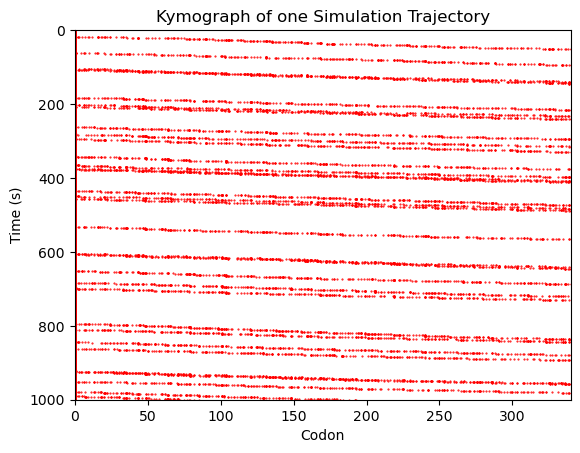

In [72]:
# Lets plot the motion of the ribosome
plot_kymograph(soln.ribosome_array[0])

In [54]:
# Where do the default rates come from? Can we change them?
largest_CDS.kelong_mat

array([[14.73279406,  9.71025063,  8.77270919, ..., 18.81779605,
         4.95557618,  1.07147593],
       [ 0.        ,  8.83967644,  8.17000398, ..., 26.51902931,
         8.83967644,  3.01352606],
       [ 0.        ,  8.83967644,  8.17000398, ..., 26.51902931,
         8.83967644,  3.01352606]])

You may have noticed we ran this simulation without explicitly defining these stepping rates from codon to condon. As a default, the Nakamura 2000 values of codon frequencies per 1000 codons to scale "fast" and "slow" codons to a desired average rate.

$k_e(i) = \bar{k_e}*(u(i)/\bar{u})$

Where $k_e(i)$ of the $i^{th}$ codon is equal to an average $\bar{k_e}$ times the ratio of the $u(i)$ codon frequency of the $i^{th}$ codon to the average codon frequency across the dictionary.

We can use a different dictionary, or our own dictionary as long as we cover every codon in a given sequence. Here we are going to replace the stepping rates with a different human codon frequency dictionary scaled to a mean of 2 codons per second.

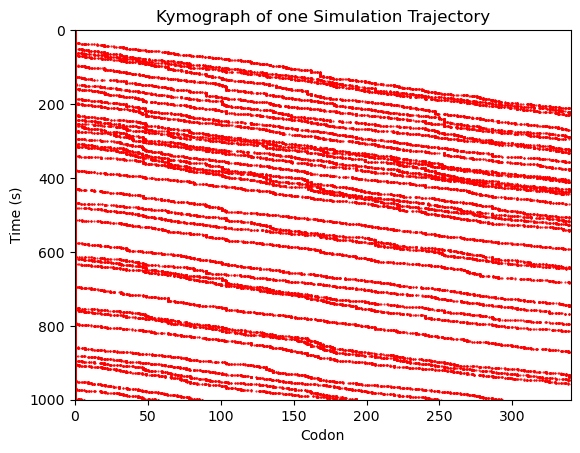

In [73]:
k_initiation = .03
k_termination = 10
stepping_rate_mean = 2

# generate a stepping rate list with the propensity_factory (propf)
stepping_rate_list = rsnp.propf.get_k(largest_CDS.nt_seq.replace('U','T'),
                                      k_initiation, stepping_rate_mean, k_termination, codon_freq_bias_dict=rsnp.aux_cdict.Human_codon_freq_HIVE)[1:-1]

t = np.linspace(0,1000,10001)
soln = rsnp.solver.solve_ssa(stepping_rate_list, t, probe_list = [], ki = k_initiation, kt=k_termination)

plot_kymograph(soln.ribosome_array[0])

We can also generate a list and edit it manually, then solve TASEP trajectories with those rates.

# Manually induce a pause at the 100th codon!

stepping_rate_list = largest_CDS.kelong
stepping_rate_list[100] = .05
stepping_rate_list[-1] = 0
t = np.linspace(0,1000,10001)

k_initiation = .03
k_termination = 10
soln = rsnp.solver.solve_ssa(stepping_rate_list, t, probe_list = [], ki = k_initiation, kt=k_termination)

plot_kymograph(soln.ribosome_array[0])

## What about the intensity trajectories?

So far we have only looked at ribosomal movement, but in the real world our data is given as the calculated intensity of a given mRNA spot over time. To calculate this from our simulations, we need to give it locations of the fluorescent epitopes so it can sum an intensity as ribosomes pass this codon.

In [19]:
soln.intensity_arr.sum() #hang on theres no intensity? Yes because we didn't tag it with any fluorescent epitopes!

0

In [20]:
rsnp.cdict.tag_dict # Here are some of our tagging options

{'T_SunTag': 'EELLSKNYHLENEVARLKK',
 'T_Flag': 'DYKDDDDK',
 'T_Hemagglutinin': 'YPYDVPDYA',
 'T_Myc': 'EQKLISEEDL',
 'T_Strep': 'WSHPQFEK',
 'T_Hist': 'HHHHHH',
 'T_V5': 'GKPIPNPLLGLDST',
 'T_TC': 'CCPGCC'}

Here we are going to make a new CDS object that has a full 10X FLAG tag appended on the front of the protein.

In [21]:
rsnp.cdict.tag_full['T_Flag'] #lets add a full 10x tflag

'ATGGACTACAAGGACGACGACGACAAAGGTGACTACAAAGATGATGACGATAAAGGCGACTATAAGGACGATGACGACAAGGGCGGAAACTCACTGATCAAGGAAAACATGCGGATGAAGGTGGTGATGGAGGGCTCCGTGAATGGTCACCAGTTCAAGTGCACCGGAGAGGGAGAGGGAAACCCGTACATGGGAACTCAGACCATGCGCATTAAGGTCATCGAAGGAGGTCCGCTGCCGTTCGCTTTCGATATCCTGGCCACTTCGTTCGGAGGAGGGTCGCGCACGTTCATCAAGTACCCGAAGGGAATCCCGGACTTCTTTAAGCAGTCATTCCCGGAAGGATTCACTTGGGAACGGGTGACCCGGTATGAAGATGGAGGTGTGGTGACTGTCATGCAAGATACTTCGCTGGAGGATGGGTGCCTCGTGTACCACGTCCAAGTCCGCGGAGTGAATTTCCCGTCCAACGGACCAGTGATGCAGAAAAAGACGAAGGGTTGGGAACCTAATACTGAAATGATGTACCCCGCAGACGGAGGGCTGAGGGGCTACACCCACATGGCGCTGAAGGTCGACGGAGGAGATTACAAGGATGACGACGATAAGCAACAAGATTACAAAGACGATGATGACAAGGGCCAGCAGGGCGACTACAAGGACGACGACGACAAGCAGCAGGACTACAAAGATGACGATGATAAAGGAGGAGGACATCTGTCCTGTTCGTTCGTGACCACCTACAGATCAAAGAAAACCGTGGGAAACATCAAGATGCCGGGCATTCATGCCGTCGACCACCGCCTGGAGCGGCTCGAAGAATCAGACAATGAGATGTTCGTCGTGCAAAGAGAACATGCCGTGGCCAAGTTCGCGGGACTGGGAGGCGGTGGAGGCGATTACAAAGACGATGATGACAAGGGTGACTATAAAGACGACGATGACAAAGGGGATTACAAGGATGATGATGATAAGGGAGGCGGTGGATCAGGTGGAGGA

In [22]:
rsnp.seqmanip.nt2aa(rsnp.cdict.tag_full['T_Flag'])

'MDYKDDDDKGDYKDDDDKGDYKDDDDKGGNSLIKENMRMKVVMEGSVNGHQFKCTGEGEGNPYMGTQTMRIKVIEGGPLPFAFDILATSFGGGSRTFIKYPKGIPDFFKQSFPEGFTWERVTRYEDGGVVTVMQDTSLEDGCLVYHVQVRGVNFPSNGPVMQKKTKGWEPNTEMMYPADGGLRGYTHMALKVDGGDYKDDDDKQQDYKDDDDKGQQGDYKDDDDKQQDYKDDDDKGGGHLSCSFVTTYRSKKTVGNIKMPGIHAVDHRLERLEESDNEMFVVQREHAVAKFAGLGGGGGDYKDDDDKGDYKDDDDKGDYKDDDDKGGGGSGGGGSLQ'

In [23]:
newseq = rsnp.cdict.tag_full['T_Flag'] + largest_CDS.nt_seq
tagged_CDS = rsnp.seqmanip.seq_to_CDS_obj(newseq)['0'][0] 
tagged_CDS.generate_3frame_tags()

Text(0, 0.5, 'probe value')

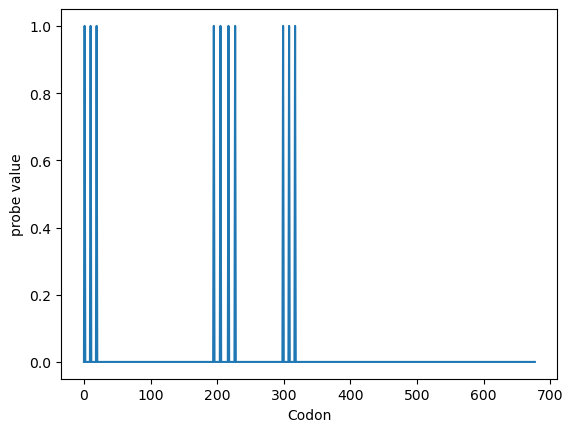

In [79]:
plt.plot(tagged_CDS.probe_mat[0,:])
plt.xlabel('Codon')
plt.ylabel('probe value')

In [80]:
t = np.linspace(0,1000,10001)
soln = rsnp.solver.solve_ssa(tagged_CDS, t)

In [26]:
soln.intensity_arr.sum() #now we should have intensity

135846

Text(0, 0.5, 'Intensity (# probes)')

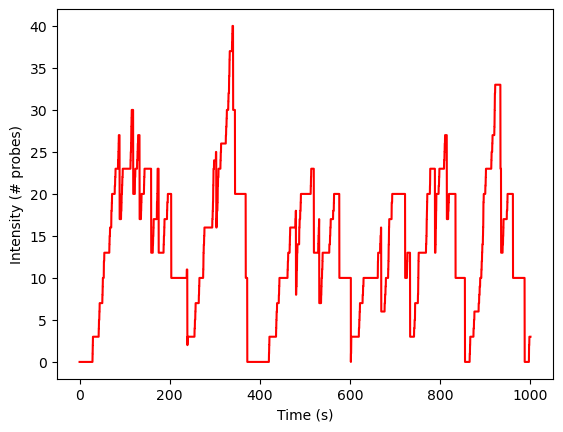

In [27]:
plt.plot(soln.t, soln.intensity_arr[0],'r')
plt.xlabel('Time (s)')
plt.ylabel('Intensity (# probes)')

## Custom TASEP models

A new feature of the rSNAPsim version 2.0 is a custom TASEP modeler.

In [28]:
# Creating an mRNA model 

# takes a CDS object and a name
mRNA_length = len(tagged_CDS.kelong) 
model = rsnp.tasep_model(tagged_CDS, 'test') # model object

In [29]:
model.__dict__

{'name': 'test',
 '_length': 678,
 'particle_size': 9,
 'footprint': 9,
 '_max_particles': 80,
 '_state_mat': array(0),
 '_probe_mat': array([[0., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 '_n_colors': 1,
 '_resource_mat': array(0),
 '_propensities': [],
 '_parameters': [],
 '_prop_ids': [],
 '_constant_rxn_bool': [],
 '_constant_reactions': [],
 '_ribosome_reactions': [],
 '_n_rxns': 0,
 '_n_pars': 0,
 '_n_kelong': 1,
 '_n_frames': 1,
 '_n_states': 0,
 '_n_resources': 0,
 '_rxn_mat': array([], shape=(0, 8), dtype=float64),
 '_TranslationModel__rxn_size': 8,
 '_TranslationModel__default_colors': ['#07BEB8',
  '#8F3985',
  '#5EDA6A',
  '#FA5E5E'],
 '_state_names': [],
 '_resource_names': [],
 '_rib_arr0': array([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0

In [30]:
## overwite the default kelongation matrix 
kelong_mat = np.zeros([3, mRNA_length+1])
kelong_mat[0, :-1] = rsnp.propf.get_k(tagged_CDS.nt_seq, .033, 10, 10)[1:-1]
kelong_mat[1, :-2] = rsnp.propf.get_k(tagged_CDS.nt_seq[1:-2], .1, 10, 10)[1:-1]
kelong_mat[2, :-2] = rsnp.propf.get_k(tagged_CDS.nt_seq[2:-1], .1, 10, 10)[1:-1]
kelong_mat[0, -2] = 0

model._kelong_mat = kelong_mat #override the current kelongation mat

footprint = 9
last_codon = len(tagged_CDS.kelong)-1 
parameters = [0.03, 0.01, 10, .4, 0]


# k is the parameters, t = timepoint, p = ribosome_array/array, occupation array, lattice array, probe matrix, state matrix
# r = resources, nr = number of ribosomes
# Check the docstring!

# Lattice based reactions, happen at specific locations, in this case the initiation and termination site
init = lambda k,t,p,ke,o,l,pr,s,r,nr: (1-np.any(l[0:0+footprint]))*k[0]
model.add_lattice_reaction(init, parameters, rxn_name = 'initiation', frame=0, loc=0, dexist=1,)

# Alternative start site
init_100 = lambda k,t,p,ke,o,l,pr,s,r,nr: (1-np.any(l[100:100+footprint]))*k[1]
model.add_lattice_reaction(init_100, parameters, rxn_name = 'initiation', frame=0, loc=100, dexist=1,)

leave = lambda k,t,p,ke,o,l,pr,s,r,nr: l[last_codon]*k[2] #(lattice location last_codon = 1) * parameter
model.add_lattice_reaction(leave, parameters, rxn_name='termination', exclusion=0, frame=0, loc=last_codon, dexist=-1,)

# ribosome based reactions
#default stepping
                                                # agent frame, agent location
elong_step = lambda k,t,p,ke,o,l,pr,s,r,nr: [ (ke[p[i,2], p[i,3]])*(1 - sum(l[p[i,3]+1:p[i,3]+footprint])) for i in range(nr)]
model.add_ribosome_reaction(elong_step, parameters, rxn_name='elongation', exclusion=1, dloc=1) 


# finally specify which reactions are ribosome specific, this should be automated in the future
model._ribosome_reactions = [3,]
model._constant_reactions = [0,1,2]
model._lattice_arr0 = np.zeros([model._length+1], dtype=int)


In [31]:
model.add_ribosome_reaction?

Signature:
model.add_ribosome_reaction(
    propensity,
    parameters,
    rxn_name='',
    exclusion=0,
    dexist=0,
    dframe=0,
    dloc=0,
    dprobes=[],
    dprobe_inds=[],
    dstates=[],
    dstate_inds=[],
    dresources=[],
    dresource_inds=[],
)
Docstring: <no docstring>
File:      c:\users\willi\documents\github\rsnapsim\rsnapsim\translationmodel.py
Type:      method

In [32]:
model.add_lattice_reaction?

Signature:
model.add_lattice_reaction(
    propensity,
    parameters,
    rxn_name='',
    frame=0,
    loc=0,
    exclusion=0,
    dexist=0,
    dframe=0,
    dloc=0,
    dprobes=[],
    dprobe_inds=[],
    dstates=[],
    dstate_inds=[],
    dresources=[],
    dresource_inds=[],
)
Docstring: <no docstring>
File:      c:\users\willi\documents\github\rsnapsim\rsnapsim\translationmodel.py
Type:      method

In [33]:
soln = rsnp.solver.solve_ssa(model, t)

Text(0, 0.5, 'Intensity (# probes)')

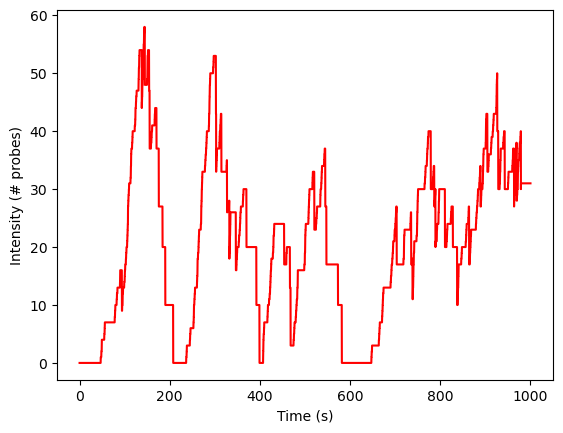

In [34]:
plt.plot(soln.t, soln.intensity_arr[0],'r')
plt.xlabel('Time (s)')
plt.ylabel('Intensity (# probes)')